In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

## Part B :

## Load Dataset ( Real Estate House Price )

In [2]:
original_data = pd.read_csv('RealEstate_HousePrice_Dataset.csv')

df = original_data.copy()

df.head(10)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566
5,100006,1498,3,1,7.4,9,13.3,2050,0,0,9,26448337
6,100007,2676,6,6,7.1,16,14.5,7215,1,0,16,44768109
7,100008,2149,2,1,5.9,19,17.4,2268,1,0,9,30291804
8,100009,1345,2,1,4.7,37,12.5,3977,0,0,32,16161989
9,100010,2003,4,3,1.0,31,18.4,5554,1,0,17,12273622


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [4]:
df.shape

(4200, 12)

## Dropping Duplicates

In [5]:
df.drop_duplicates()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,104196,1328,4,2,4.9,21,19.6,2606,1,0,21,18319188
4196,104197,2363,6,4,6.9,53,24.9,4013,1,0,14,40340976
4197,104198,632,2,2,4.5,27,19.4,1268,1,0,6,5978595
4198,104199,450,2,2,7.5,26,11.6,800,0,0,9,7916191


## EDA ( Exploratory Data Analysis )

### Univariate Analysis

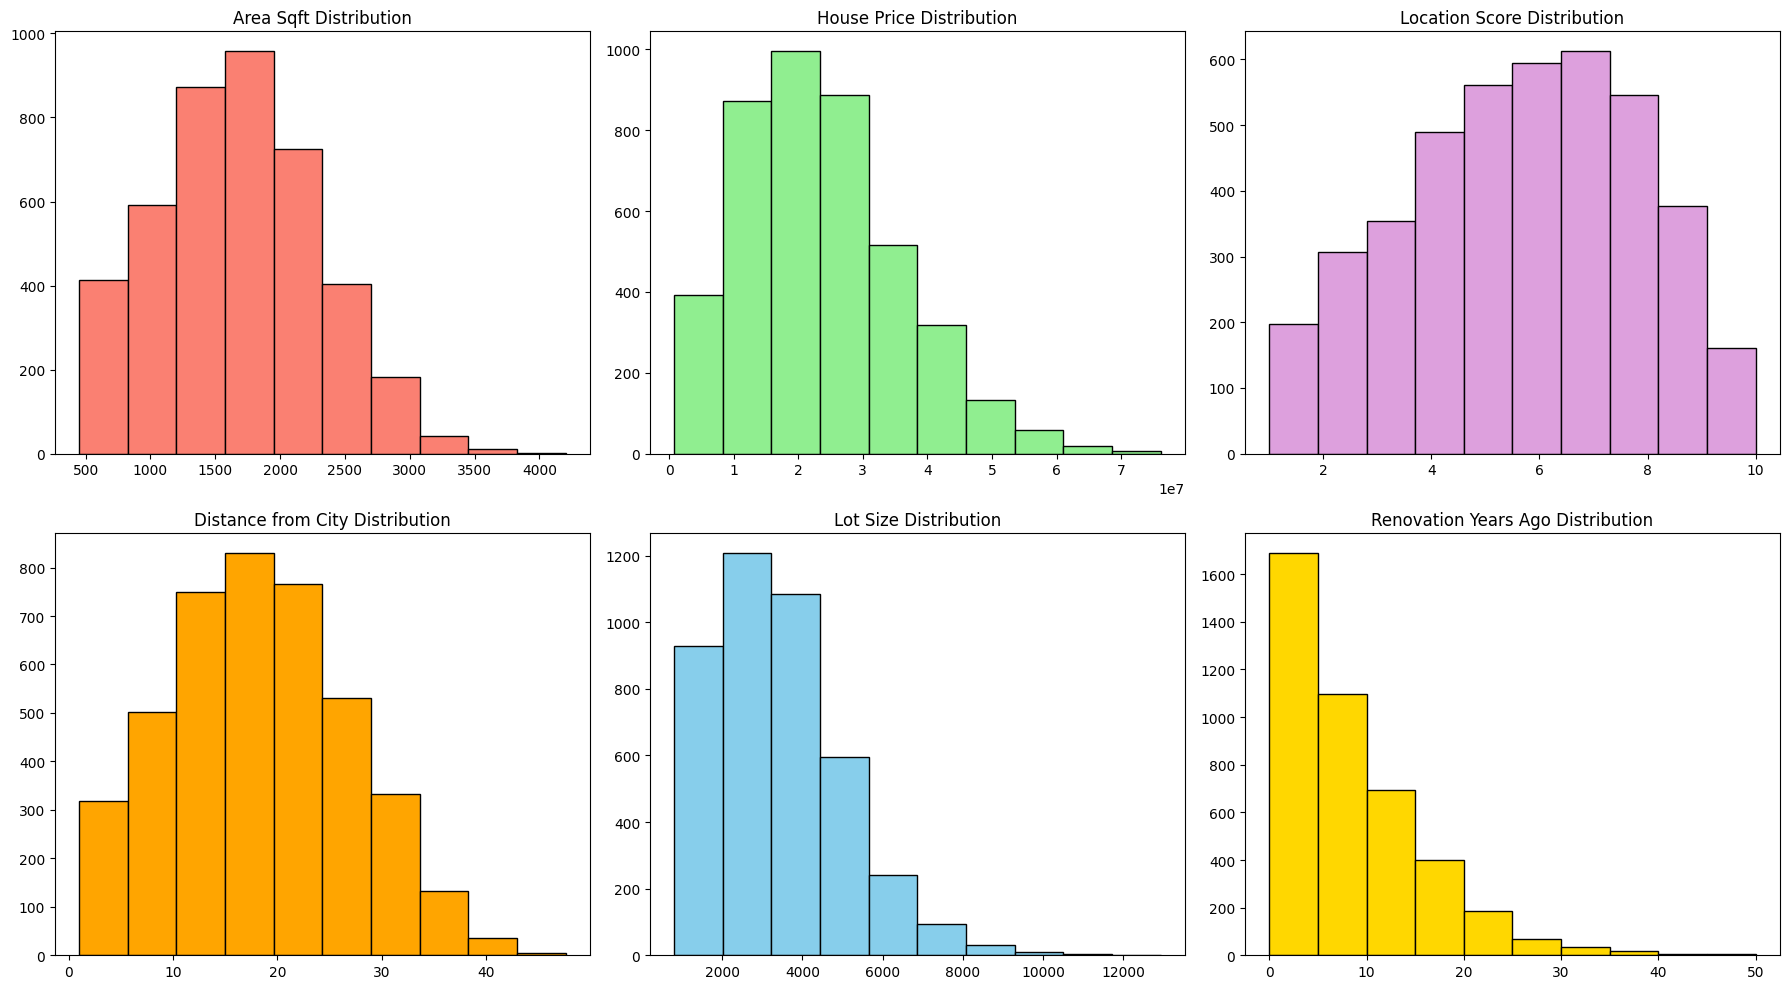

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(18,10))

ax[0,0].hist(df['area_sqft'], color='salmon', edgecolor='black')

ax[0,0].set_title("Area Sqft Distribution")

ax[0,1].hist(df['house_price_inr'], color='lightgreen', edgecolor='black')

ax[0,1].set_title("House Price Distribution")

ax[0,2].hist(df['location_score'], color='plum', edgecolor='black')

ax[0,2].set_title("Location Score Distribution")

ax[1,0].hist(df['distance_city_km'], color='orange', edgecolor='black')

ax[1,0].set_title("Distance from City Distribution")

ax[1,1].hist(df['lot_size_sqft'], color='skyblue', edgecolor='black')

ax[1,1].set_title("Lot Size Distribution")

ax[1,2].hist(df['renovation_years_ago'], color='gold', edgecolor='black')

ax[1,2].set_title("Renovation Years Ago Distribution")

plt.tight_layout()
plt.show()

### According to the above visuals, it shows that all the features had slight Right Skewness except Location Score.

### Bivariate Analysis 

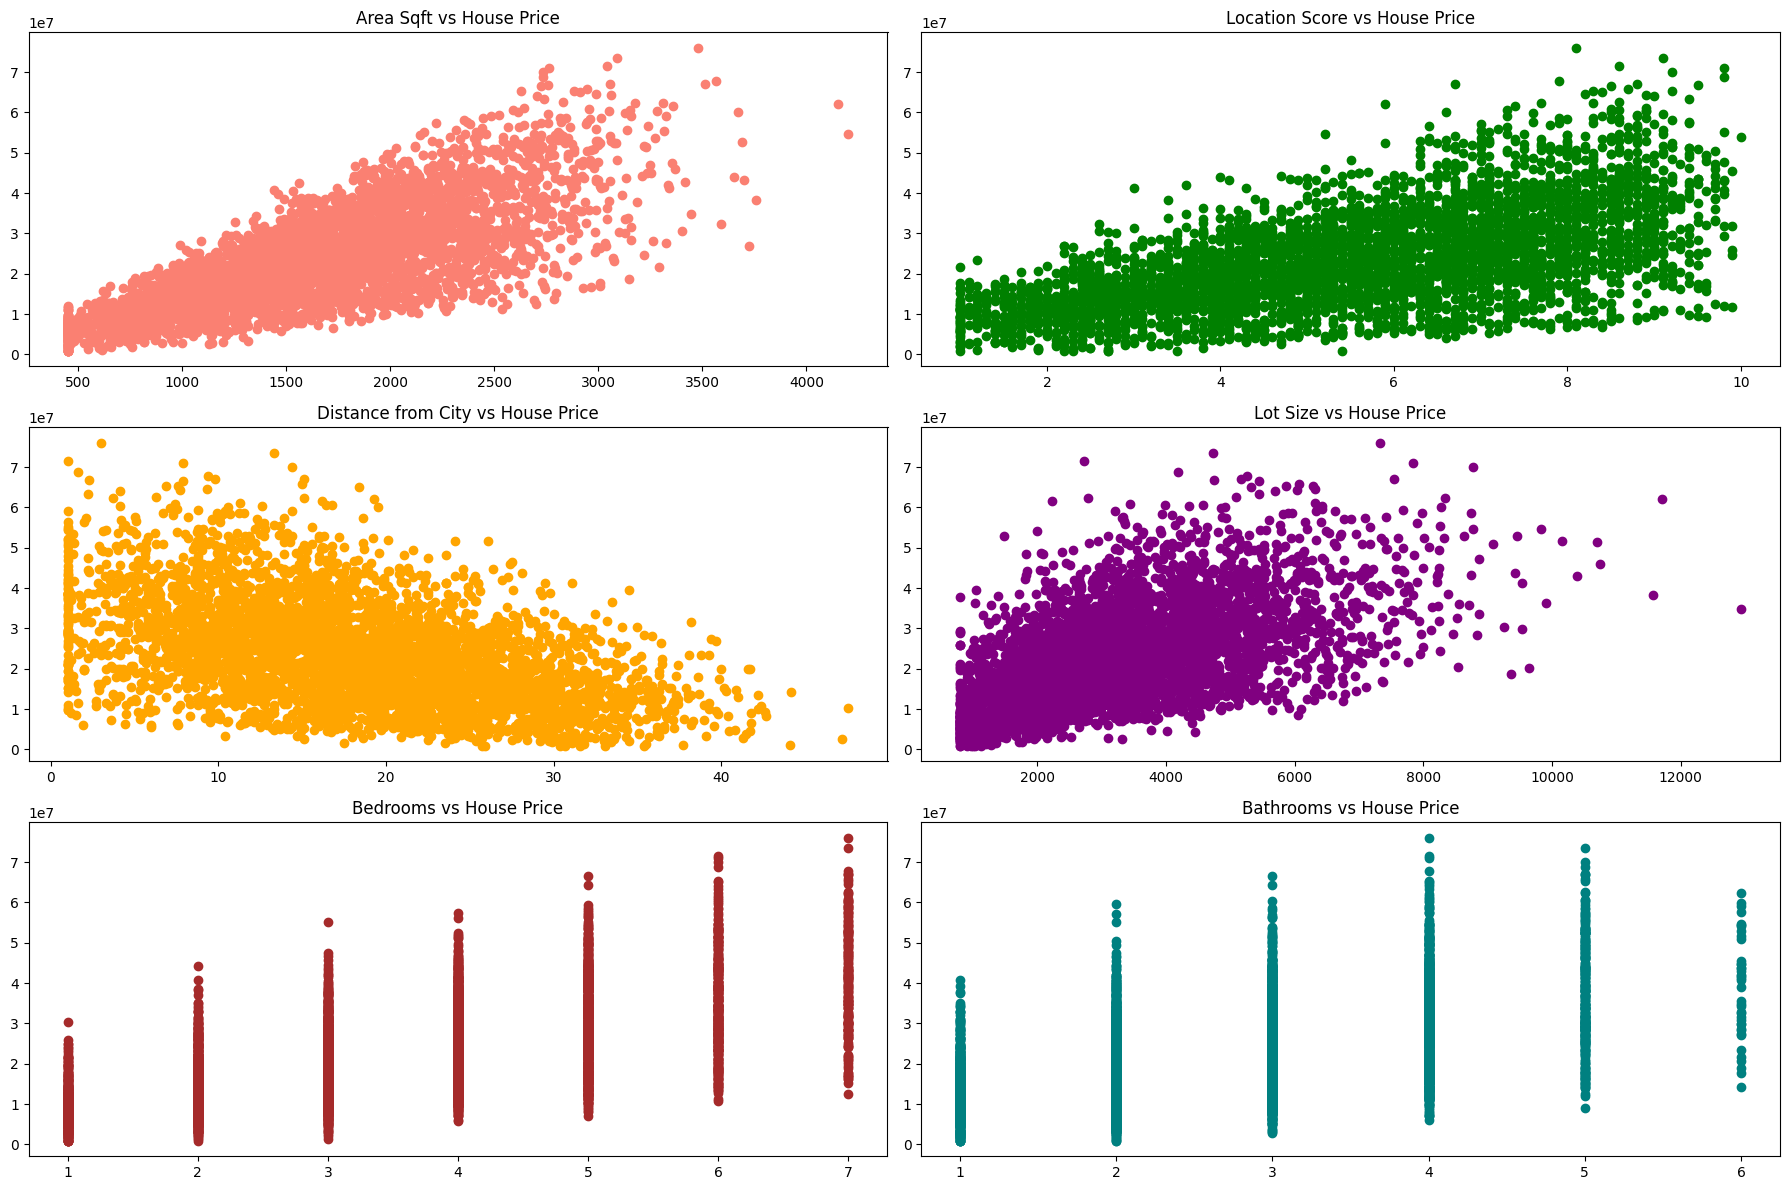

In [7]:
fig, ax = plt.subplots(3 , 2, figsize=(18,12))

ax[0,0].scatter(df['area_sqft'], df['house_price_inr'],color='salmon')

ax[0,0].set_title("Area Sqft vs House Price")

ax[0,1].scatter(df['location_score'], df['house_price_inr'],color='green')

ax[0,1].set_title("Location Score vs House Price")

ax[1,0].scatter(df['distance_city_km'], df['house_price_inr'],color='orange')

ax[1,0].set_title("Distance from City vs House Price")

ax[1,1].scatter(df['lot_size_sqft'], df['house_price_inr'], color='purple')

ax[1,1].set_title("Lot Size vs House Price")

ax[2,0].scatter(df['bedrooms'], df['house_price_inr'], color='brown')

ax[2,0].set_title("Bedrooms vs House Price")

ax[2,1].scatter(df['bathrooms'], df['house_price_inr'], color='teal')

ax[2,1].set_title("Bathrooms vs House Price")

plt.tight_layout()

plt.show()

### According to above visuals, there is significant relationship between Area Sqft , Location , Lot size sqft and bedroom with target variable (House Price). 

### Multivariate Analysis

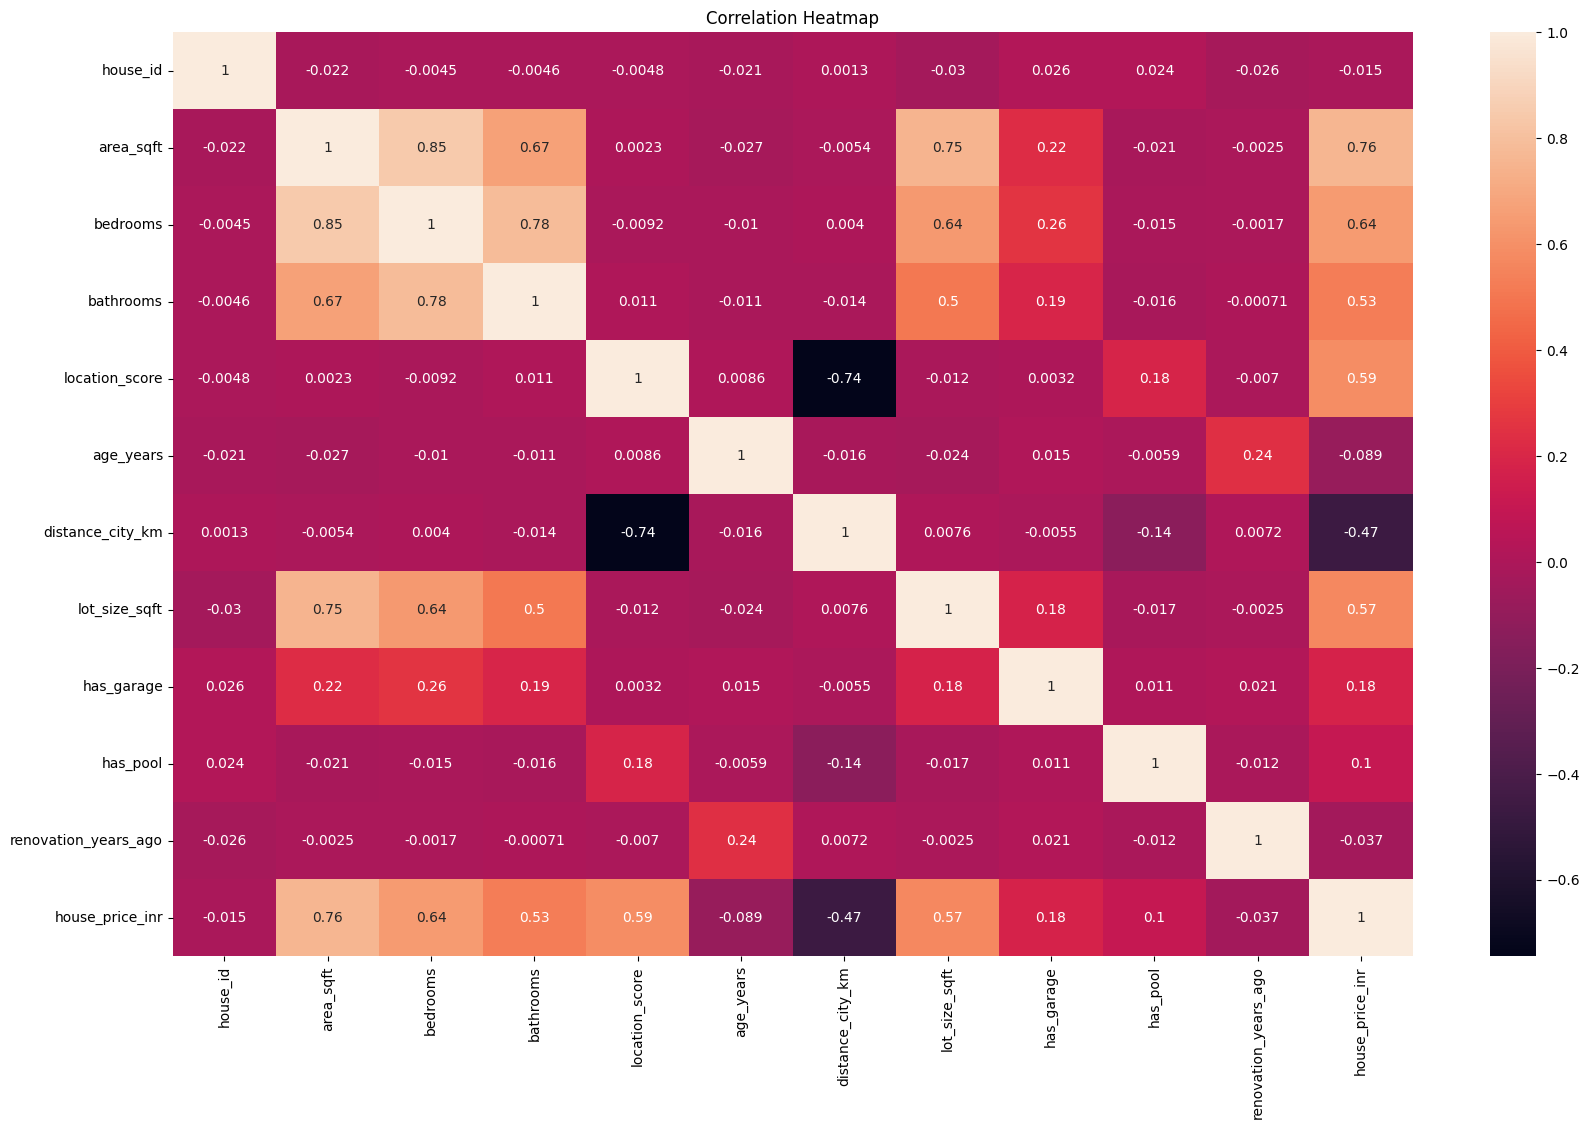

In [8]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Dropping Unnecessary Features

In [9]:
df = df.drop(columns=['house_id'])

### We may also drop features like 'has_pool' , 'renovation_years_ago' , 'age_years' and 'has_garage' if result wont get apprpriate. In the initial it was kept, if model not performed well, then those features are dropped to check improvement.

### When the features with low degree of correlation dropped, the result in Accuracy id dropped ( approx. 0.5 - 1 % ). So those features are can be kept or not.

## Missing Value Identification

In [10]:
null_count = df.isnull().sum()
null_percent = ( null_count / len(df) ) * 100

missing_df = pd.DataFrame({
    'Missing Count' : null_count,
    'Missing Perecent (%) ' : null_percent,
})

missing_df

,Missing Count,Missing Perecent (%)
area_sqft,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
location_score,0,0.0
age_years,0,0.0
distance_city_km,0,0.0
lot_size_sqft,0,0.0
has_garage,0,0.0
has_pool,0,0.0
renovation_years_ago,0,0.0


## Train-Test Split

In [11]:
X = df.drop('house_price_inr' , axis=1)
y = df['house_price_inr']

In [12]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state=10)

## Identifying Outlier

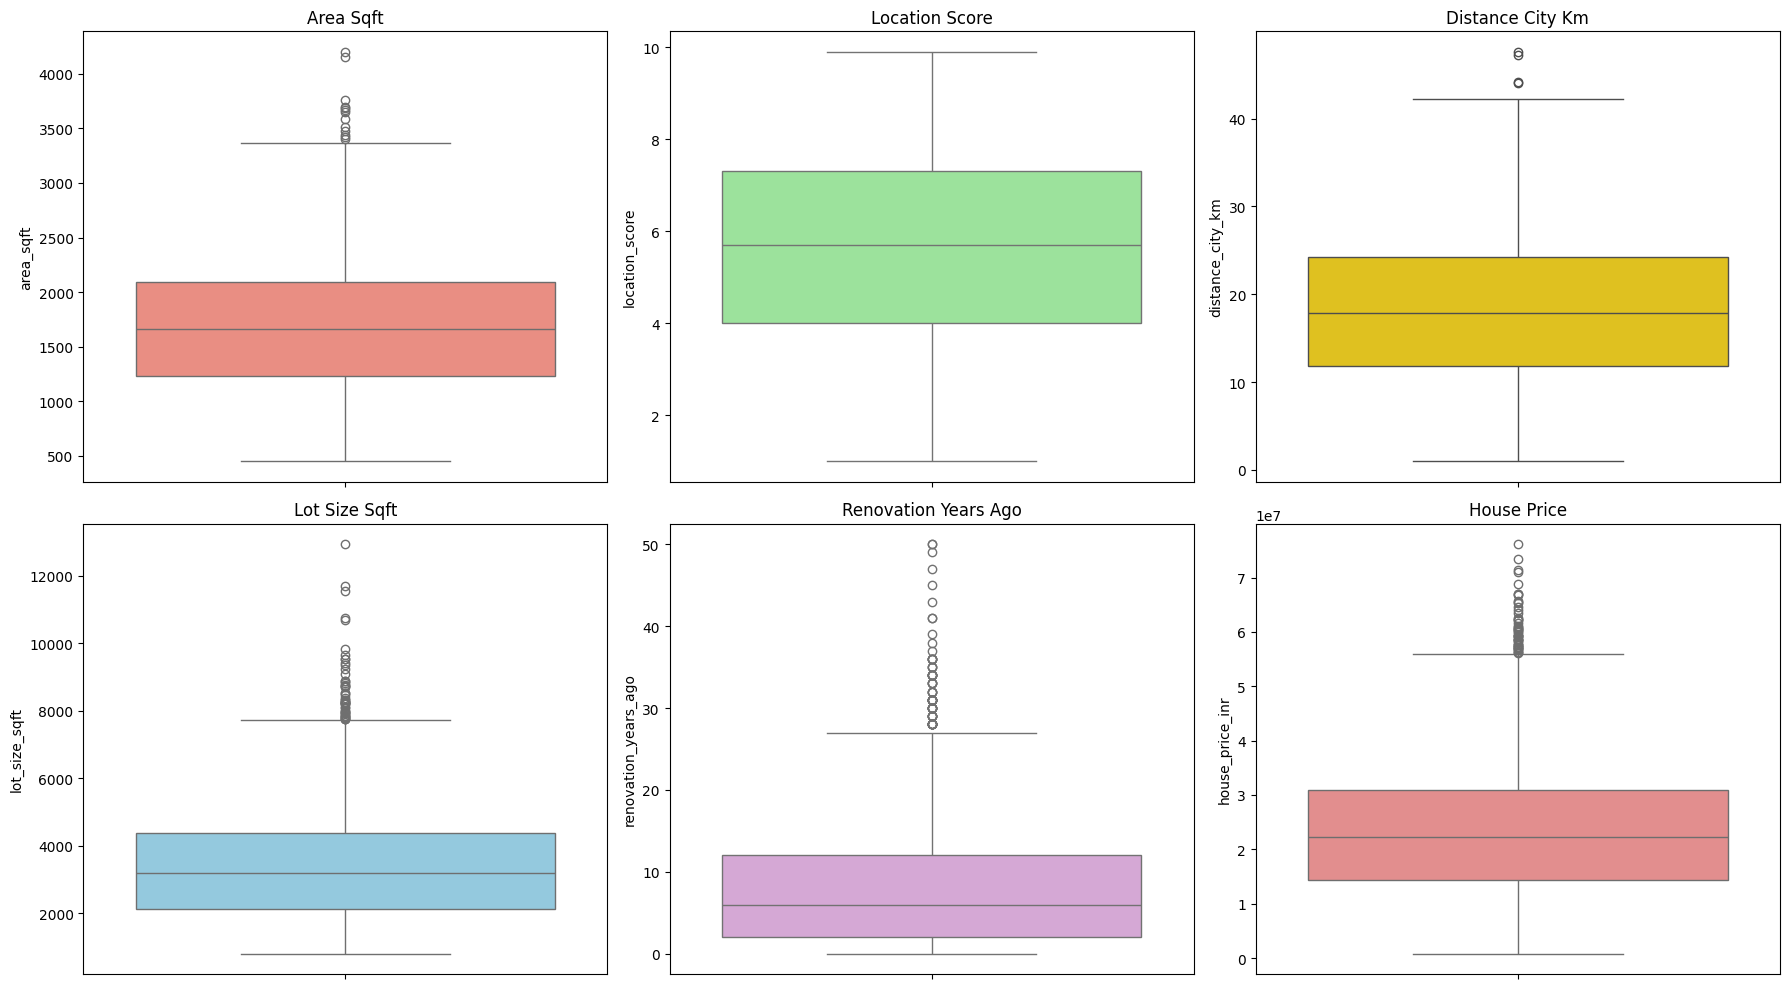

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(18,10))

sns.boxplot(y=X_train['area_sqft'], ax=ax[0,0], color='salmon')

ax[0,0].set_title("Area Sqft")

sns.boxplot(y=X_train['location_score'], ax=ax[0,1], color='lightgreen')

ax[0,1].set_title("Location Score")

sns.boxplot(y=X_train['distance_city_km'], ax=ax[0,2], color='gold')

ax[0,2].set_title("Distance City Km")

sns.boxplot(y=X_train['lot_size_sqft'], ax=ax[1,0], color='skyblue')

ax[1,0].set_title("Lot Size Sqft")

sns.boxplot(y=X_train['renovation_years_ago'], ax=ax[1,1], color='plum')

ax[1,1].set_title("Renovation Years Ago")

sns.boxplot(y=y_train, ax=ax[1,2], color='lightcoral')

ax[1,2].set_title("House Price")

plt.tight_layout()
plt.show()

### According to above visuals  of boxplot, it seems like there exist outlier in every features which is displayed above except Location Score.

### The outliers which may be seem there( in features ) is not being removed or capped because they may seem correct and may involve some useful information. 

## Feature Engineering 

In [14]:
X_train['total_rooms'] = X_train['bedrooms'] + X_train['bathrooms']

X_test['total_rooms'] = X_test['bedrooms'] + X_test['bathrooms']

### This feature is created because prices of house is generally more valuable for more number of rooms as well as bathrooms. So in this feature both bathrooms and rooms are added to define total number of rooms.

In [15]:
X_train['premium_location'] = (X_train['location_score'] >= 7.7).astype(int)

X_test['premium_location'] = (X_test['location_score'] >= 7.7).astype(int)

### This feature is created because prices of house differ from the area around house. If Location is good prices are usually high .

## Encoding 

### Encoding is also not happen here because there is no categorical feature.

## Feature Scaling 

In [16]:
robust_scaler = RobustScaler()

X_train_Scaled = robust_scaler.fit_transform(X_train)

X_test_Scaled = robust_scaler.transform(X_test)

### Given the presence of moderate outliers in several numerical features, RobustScaler is the most appropriate scaling technique for this dataset, as it reduces the influence of extreme values while preserving the underlying feature distributions. We may check an the Accuracy of model by using Standard Scaler.

## SLR ( Simple Linear Regression )

In [17]:
X_train_SLR = X_train[['area_sqft']]

X_test_SLR = X_test[['area_sqft']]

In [18]:
robust_scaler_SLR = RobustScaler()

X_train_SLR = robust_scaler_SLR.fit_transform(X_train_SLR)
X_test_SLR = robust_scaler_SLR.transform(X_test_SLR)

In [19]:
SLR_model = LinearRegression()

SLR_model.fit(X_train_SLR , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred_SLR = SLR_model.predict(X_test_SLR)

In [21]:
print("Slope :", SLR_model.coef_[0])
print("Intercept :", SLR_model.intercept_)

Slope : 12748530.220514512
Intercept : 23533830.790105574


In [22]:
print('MSE :' , mean_squared_error( y_test , y_pred_SLR ))

print('RMSE :' ,root_mean_squared_error( y_test , y_pred_SLR ))

print('MAE :' , mean_absolute_error( y_test , y_pred_SLR ))

R2_Score_SLR= r2_score(y_test, y_pred_SLR)

print( "SLR R2 Score:", R2_Score_SLR)

MSE : 60582085825696.664
RMSE : 7783449.481155297
MAE : 6007708.188113025
SLR R2 Score: 0.6008786697831816


#### The model has some large prediction errors, which significantly increase the MSE value.(MSE)
#### On average, the model's predictions are off by approximately Rs.77,83,500.(RMSE)
#### On average, the model makes an error of about Rs.60,07,700 per house prediction.(MAE)
#### The model explains approximately 60.09% of the variation in house prices, while 39.91% remains unexplained.(R2 Score)

In [23]:
train_r2 = SLR_model.score(X_train_SLR, y_train)

test_r2 = SLR_model.score(X_test_SLR, y_test)

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.5632014459740702
Test R2 : 0.6008786697831816


### The train and test R2 scores are very close, indicating that the SLR model generalizes well and does not show signs of overfitting or underfitting . However, the model explains only about 60% of the variation in house prices, suggesting that area alone is insufficient for accurate prediction.

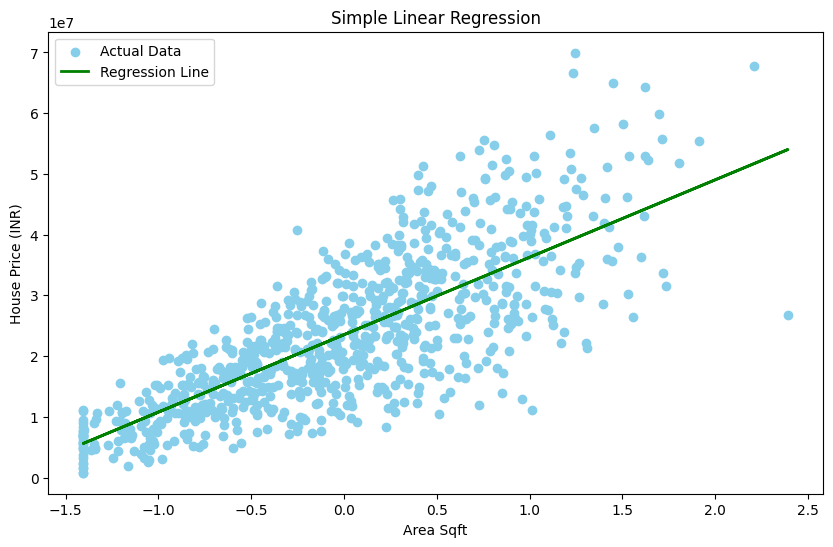

In [24]:
plt.figure(figsize=(10,6))


plt.scatter( X_test_SLR , y_test , color='skyblue' , label='Actual Data')

plt.plot( X_test_SLR , y_pred_SLR , color='green' , linewidth=2 , label='Regression Line')

plt.title("Simple Linear Regression")
plt.xlabel("Area Sqft")
plt.ylabel("House Price (INR)")
plt.legend()

plt.show()

### So When SLR ( Simple Linear Regression with 2 features only ) performed it gaves us an Accuracy of 60%

## MLR ( Multiple Linear Regression )

In [25]:
MLR_model = LinearRegression()

MLR_model.fit(X_train_Scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred_MLR = MLR_model.predict(X_test_Scaled)

In [27]:
R2_Score_MLR = r2_score(y_test, y_pred_MLR)

print( "R2 Score:", R2_Score_MLR )

n = X_test_Scaled.shape[0]
p = X_test_Scaled.shape[1]

Adjusted_R2 = 1- ( (1 - R2_Score_MLR) * (n - 1) / (n - p - 1) )

print("Adjusted R2 Score :", Adjusted_R2)

R2 Score: 0.9253618820428845
Adjusted R2 Score : 0.9242788621934463


In [28]:
train_r2 = MLR_model.score(X_train_Scaled, y_train)

test_r2 = MLR_model.score(X_test_Scaled, y_test)

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.9233473900262452
Test R2 : 0.9253618820428845


### The train and test R2 scores are very close, indicating that the Multiple Linear Regression model generalizes well to unseen data. Therefore, there is no significant evidence of overfitting or underfitting. The model demonstrates strong predictive performance and stability.

### So therefore, When performed MLR ( Multiple Linear Regression ) it gives us an Accuracy of 92% while, SLR just gave 60% Accuracy .

### There is significant improvement when performed MLR because it does not only use Area Sqft, but also uses features such as Location Score , Bedrooms , Bathrooms , Lot size Sqft ,etc. as a result MLR captures more information and makes more accurate predictions.

## Polynomial Regression 

In [29]:
Polynomial = PolynomialFeatures( degree = 2 )

X_train_PR = Polynomial.fit_transform(X_train_Scaled)

X_test_PR = Polynomial.transform(X_test_Scaled)

In [30]:
PR_model = LinearRegression()

PR_model.fit( X_train_PR , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred_PR = PR_model.predict ( X_test_PR )

In [32]:
R2_Score_PR = r2_score(y_test , y_pred_PR)

print( "R2 Score:", R2_Score_PR)

R2 Score: 0.9640425076905951


In [33]:
train_r2 = PR_model.score(X_train_PR, y_train)

test_r2 = PR_model.score(X_test_PR, y_test)

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.9695332094998237
Test R2 : 0.9640425076905951


### So therefore, When performed PR ( Polynomial Regression ) it gives us an Accuracy of 96%

### The Polynomial Regression model achieved a training R2 score of 0.969 and a testing R2 score of 0.964. The very small difference between the two scores indicates strong generalization and minimal overfitting. Compared to Simple Linear Regression, Polynomial Regression significantly improved predictive performance by capturing non-linear relationships among the features, explaining approximately 96.4% of the variation in house prices on unseen data.

In [34]:
comparison = pd.DataFrame({
    'Model' : ['SLR' , 'MLR' , 'Polynomial Regression'],
    'R2 Score' : [R2_Score_SLR , R2_Score_MLR , R2_Score_PR],
})

comparison

,Model,R2 Score
0,SLR,0.600879
1,MLR,0.925362
2,Polynomial Regression,0.964043


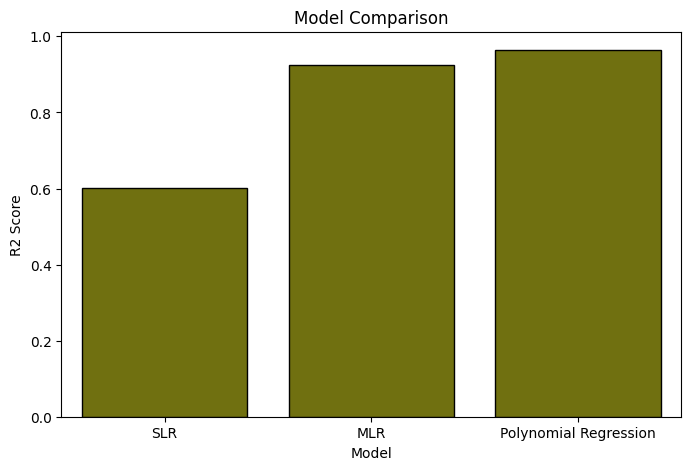

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model' , y='R2 Score' , data=comparison , color= 'olive' , edgecolor = 'black')

plt.title("Model Comparison")

plt.show()

## Gradient Descent 

### Gradient Descent is an optimization algorithm used to minimize the error (cost function) of a machine learning model.

### It works by repeatedly updating model parameters in the opposite direction of the gradient (slope) of the cost function.

### The goal is to reach the minimum point of the cost function where prediction error is lowest.

### There are 3 types of Gradient Descent :

### 1. Batch Gradient Descent ( BGD )
### 2. Stochastic Gradient Descent ( SGD )
### 3. Mini-Batch Gradient Descent ( MBGD )

## Simple Linear Regression (Batch Gradient Descent)

In [37]:
X = X_train_SLR.flatten()
y = y_train.values

n = len(X)

theta_0 = 0
theta_1 = 0

learning_rate = 0.001
epochs = 3000
cost_history_1 = []

for i in range(epochs):

    y_pred = theta_0 + theta_1 * X

    partial_theta_0 = (1/n) * np.sum(y_pred - y)
    partial_theta_1 = (1/n) * np.sum((y_pred - y) * X)

    theta_0 = theta_0 - learning_rate * partial_theta_0
    theta_1 = theta_1 - learning_rate * partial_theta_1

    cost_function = (1/(2*n)) * np.sum((y_pred - y)**2)
    cost_history_1.append(cost_function)

print("Intercept:", theta_0)
print("Slope:", theta_1)

Intercept: 22406536.139926624
Slope: 10258247.36828608


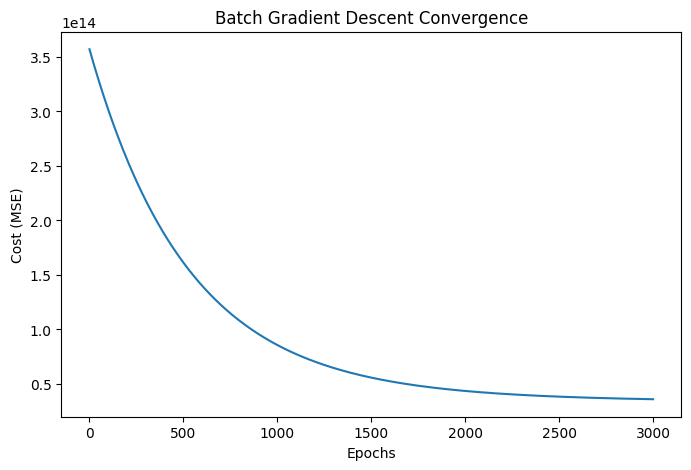

In [38]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_1)

plt.title("Batch Gradient Descent Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")

plt.show()

### The cost function decreased rapidly during the initial epochs and stabilized after approximately 4000–5000 epochs. Beyond this point, improvements were negligible.

### Multiple Linear Regression (Batch Gradient Descent)

In [39]:
X = X_train_Scaled
y = y_train.values

weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.001
epochs = 3000

cost_history_2 = []

n = len(y)

for epoch in range(epochs):

    y_pred_1 = np.dot(X, weights) + bias

    error = y_pred_1 - y

    delta_w = (1/n) * np.dot(X.T, error)
    delta_b = (1/n) * np.sum(error)

    weights = weights - learning_rate * delta_w
    bias = bias - learning_rate * delta_b

    cost_function = (1/(2*n)) * np.sum(error**2)

    cost_history_2.append(cost_function)

print('Weights : ' , weights)
print('Bias : ', bias)

Weights :  [ 6166313.97466088  1530884.07935073   625812.70751422  4982656.40330402
  -316474.85810269 -3280047.37053172  3846133.26098731 -4002514.49064756
  2062670.20794016   936849.29278207  1437797.85790997  5367708.69322536]
Bias :  20045476.29993449


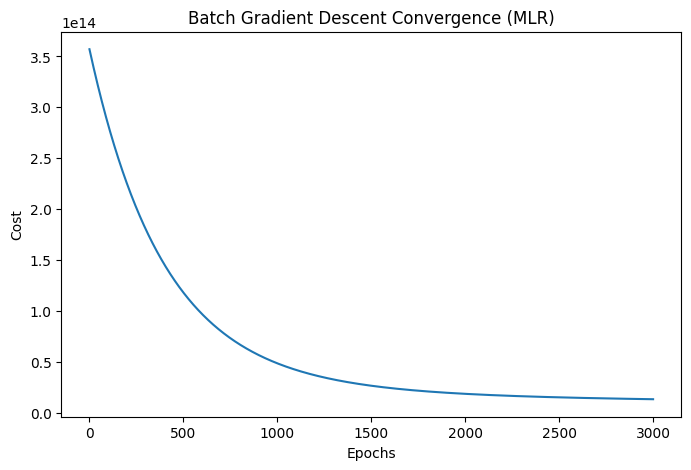

In [40]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_2)

plt.title("Batch Gradient Descent Convergence (MLR)")
plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

### In Simple Linear Regression, Gradient Descent updates one slope and one intercept. In Multiple Linear Regression, the same Batch Gradient Descent algorithm is used, but a separate weight is updated for each feature. The optimization process remains unchanged; only the number of parameters increases.

## Simple Linear Regression ( SGD )

In [42]:
X = X_train_SLR.flatten()
y = y_train.values

n = len(X)

theta_0 = 0
theta_1 = 0

learning_rate = 0.001
epochs = 10

cost_history_SGD_1 = []

for s in range(epochs):

    for i in range(n):

        x_i = X[i]
        y_i = y[i]

        y_pred_2 = theta_0 + theta_1 * x_i

        delta_theta_0 = (y_pred_2 - y_i)
        delta_theta_1 = (y_pred_2 - y_i) * x_i

        theta_0 = theta_0 - learning_rate * delta_theta_0
        theta_1 = theta_1 - learning_rate * delta_theta_1

    predictions = theta_0 + theta_1 * X
    cost_function = (1/(2*n)) * np.sum((predictions - y)**2)

    cost_history_SGD_1.append(cost_function)

print("Theta0:", theta_0)
print("Theta1:", theta_1)

Theta0: 23414962.27892339
Theta1: 12864426.507298708


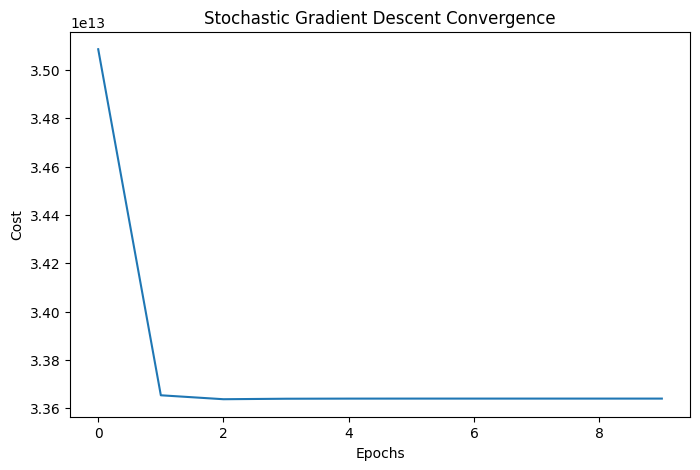

In [43]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_SGD_1)

plt.title("Stochastic Gradient Descent Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

### In Batch Gradient Descent, weights are updated after processing the entire dataset. In Stochastic Gradient Descent, weights are updated after every single training example, making it faster but more noisy.

## Multiple Linear Regression ( SGD )

In [45]:
X = X_train_Scaled
y = y_train.values


weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.001
epochs = 15

cost_history_SGD_2 = []

n = len(y)

for epoch in range(epochs):

    for i in range(n):

        x_i = X[i]
        y_i = y[i]

       
        y_pred_3 = np.dot(x_i, weights) + bias

        
        error = y_pred_3 - y_i

        
        delta_w = error * x_i
        delta_b = error

        
        weights = weights - learning_rate * delta_w
        bias = bias - learning_rate * delta_b

    
    predictions = np.dot(X, weights) + bias

    cost_function = (1/(2*n)) * np.sum((predictions - y)**2)

    cost_history_SGD_2.append(cost_function)

print("Weights : ", weights)
print("Bias : " , bias)


Weights :  [11889451.127296     297445.20031651   132814.03771202  9661320.83050791
 -1141193.81360212 -1288709.69361399   217985.59192961   102334.62224782
   330141.81015149  -242015.62673203   286839.49201902  1109211.98257441]
Bias :  24010372.56686995


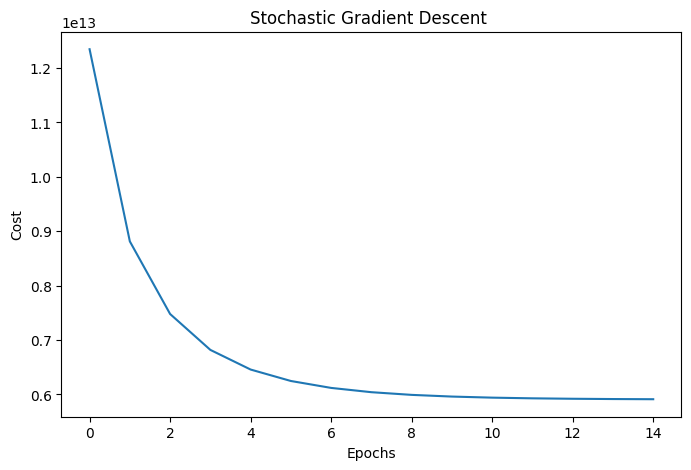

In [47]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_SGD_2)

plt.title("Stochastic Gradient Descent ")
plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

### Batch Gradient Descent does a smooth and stable convergence pattern because gradients were computed using the entire dataset before each update. Stochastic Gradient Descent converged faster initially but produced a noisier cost curve due to frequent parameter updates based on individual training samples. 

In [48]:
X = np.array(X_train_SLR).flatten()
y = np.array(y_train)

theta0 = 0
theta1 = 0

learning_rate = 0.001
epochs = 40
batch_size = 32

m = len(X)

cost_history_3 = []

for i in range(epochs):

    indices = np.random.permutation(m)

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    
    for i in range(0, m, batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        batch_m = len(X_batch)

       
        y_pred = theta0 + theta1 * X_batch

       
        d_theta0 = (1/batch_m) * np.sum(y_pred - y_batch)
        d_theta1 = (1/batch_m) * np.sum((y_pred - y_batch) * X_batch)

        
        theta0 = theta0 - learning_rate * d_theta0
        theta1 = theta1 - learning_rate * d_theta1

    
    y_pred_full = theta0 + theta1 * X

    cost = (1/(2*m)) * np.sum((y_pred_full - y)**2)

    cost_history_3.append(cost)

print("Intercept:", theta0)
print("Slope:", theta1)

Intercept: 23206523.630077783
Slope: 11441810.6071293


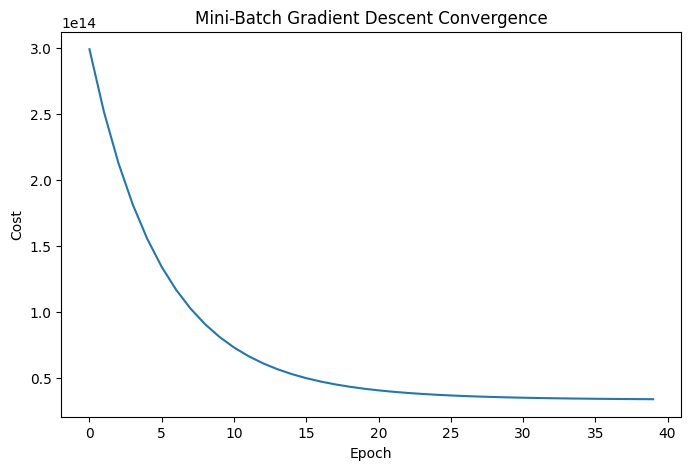

In [49]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_3)

plt.title("Mini-Batch Gradient Descent Convergence")
plt.xlabel("Epoch")
plt.ylabel("Cost")

plt.show()

In [50]:
X = np.array(X_train_Scaled)
y = np.array(y_train)

m, n = X.shape

weights = np.zeros(n)
bias = 0

learning_rate = 0.001
epochs = 40
batch_size = 32

cost_history_4 = []

for i in range(epochs):

    indices = np.random.permutation(m)

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for p in range(0, m, batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        batch_m = len(X_batch)

        y_pred = np.dot(X_batch, weights) + bias

       
        dw = (1/batch_m) * np.dot(X_batch.T, (y_pred - y_batch))
        db = (1/batch_m) * np.sum(y_pred - y_batch)

        
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

    
    y_pred_full = np.dot(X, weights) + bias

    cost = (1/(2*m)) * np.sum((y_pred_full - y)**2)

    cost_history_4.append(cost)

print("Bias:", bias)
print("Weights:", weights)

Bias: 20880531.748603746
Weights: [ 6966778.62152908  1593686.44820934   570859.2445299   5485238.13960368
  -709848.70241334 -2969240.43169786  2854607.86959844 -3290404.42055927
  2196984.30009163   452316.33728081  1443030.46182615  5964626.71319003]


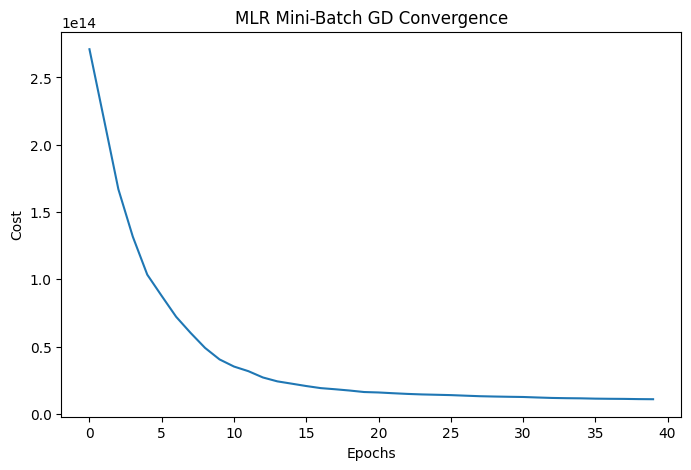

In [51]:
plt.figure(figsize=(8,5))

plt.plot(cost_history_4)

plt.title("MLR Mini-Batch GD Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

### Comparison of Gradient Descent Techniques

### Batch Gradient Descent (BGD): BGD uses the entire training dataset before updating the model parameters. It provides smooth and stable convergence but takes longer to train because every update requires processing all observations.

### Stochastic Gradient Descent (SGD): SGD updates the model parameters after each training observation. It learns faster than BGD but the convergence path is noisy because updates are based on individual samples.

### Mini-Batch Gradient Descent (MBGD): MBGD updates parameters using small batches of data instead of the full dataset or a single observation. It offers a balance between training speed and convergence stability, making it more practical for real-world machine learning problems.

## Part H : Bias - Variance & Model Diagnostic

### SLR Model has Low Complexity because it include only 1 feature (Input). Also SLR model has the Lowest Predictive performance ( around 60 % )among all models. Unable to capture other important features which affects House Price. There is High Bias and Low Variance.

### MLR Model has Medium Complexity compared to Polynomial Regression. There is Significant improvement in performance ( around 92 % ) over SLR. Also it captures important features which affects House Price. Training and Test Scores are very close which indicates Low Overfitting and also Medium Bias and Medium Variance.

### Polynomial Regression has Highest Complexity because it creates additional polynomial features. There is slight rise in performance ( around 3-4% ) from MLR model. It rises because it also captures non-linear relationship between variable which improves efficiency. Training and Test Scores are very close which indicates Low Overfitting and also Medium Bias and Medium Variance.

### Simple Linear Regression suffered from high bias due to its simplicity and unable to capture complex relationships in data. Multiple Linear Regression significantly improved performance by using multiple predictors and achieved a strong balance between bias and variance. Polynomial Regression delivered the highest predictive accuracy with a Test R2 score of 0.9640 while maintaining a small gap between training and testing performance. Therefore, Polynomial Regression provides the best balance between bias and variance for this housing price prediction dataset.